In [ ]:
mimic_icu_path = "/mnt/bbj-lab/users/burkh4rt/processed/mimic-icu"
ucmc_icu_path = "/mnt/bbj-lab/users/burkh4rt/processed/ucmc-icu"
nu_icu_path = "/mnt/bbj-lab/users/burkh4rt/processed/nu-icu"

In [2]:
import polars as pl
import yaml

site_paths = {
    "mimic-icu": mimic_icu_path,
    "ucmc-icu": ucmc_icu_path,
    "nu-icu": nu_icu_path,
}


def load_vocab(path: str) -> dict[int, str]:
    with open(f"{path}/tokenizer.yaml") as f:
        lookup = yaml.safe_load(f)["lookup"]
    return {token_id: token for token, token_id in lookup.items()}


vocabs = {site: load_vocab(path) for site, path in site_paths.items()}

tokens_times = {
    site: pl.scan_parquet(f"{path}/tokens_times.parquet").with_columns(
        pl.col("tokens").list.eval(
            pl.element().replace_strict(vocabs[site], return_dtype=pl.String)
        )
    )
    for site, path in site_paths.items()
}

In [3]:
def token_stats(lf: pl.LazyFrame) -> pl.DataFrame:
    n_timelines = lf.select(pl.len()).collect().item()
    return (
        lf.select("subject_id", "tokens")
        .explode("tokens", empty_as_null=True)
        .rename({"tokens": "token"})
        .group_by("token")
        .agg(
            pl.len().alias("n_occurrences"),
            pl.col("subject_id").n_unique().alias("n_timelines_with_token"),
        )
        .with_columns(
            (pl.col("n_timelines_with_token") / n_timelines).alias("prevalence"),
            (pl.col("n_occurrences") / pl.col("n_occurrences").sum()).alias("frequency"),
        )
        .sort("token")
        .collect(engine="streaming")
    )


token_stats_by_site = pl.concat(
    token_stats(lf).with_columns(pl.lit(site).alias("site"))
    for site, lf in tokens_times.items()
)
token_stats_by_site

token,n_occurrences,n_timelines_with_token,prevalence,frequency,site
str,u32,u32,f64,f64,str
"""ADMN//direct""",65,65,0.001884,9.8328e-7,"""mimic-icu"""
"""ADMN//ed""",29486,29486,0.854791,0.000446,"""mimic-icu"""
"""ADMN//elective""",4944,4944,0.143325,0.000075,"""mimic-icu"""
"""AGE//age_Q0""",3210,3210,0.093057,0.000049,"""mimic-icu"""
"""AGE//age_Q1""",3530,3530,0.102334,0.000053,"""mimic-icu"""
…,…,…,…,…,…
"""XFR-OUT//l&d""",834,290,0.00441,0.000005,"""nu-icu"""
"""XFR-OUT//other""",2456,2220,0.03376,0.000015,"""nu-icu"""
"""XFR-OUT//procedural""",63220,36934,0.561666,0.000399,"""nu-icu"""


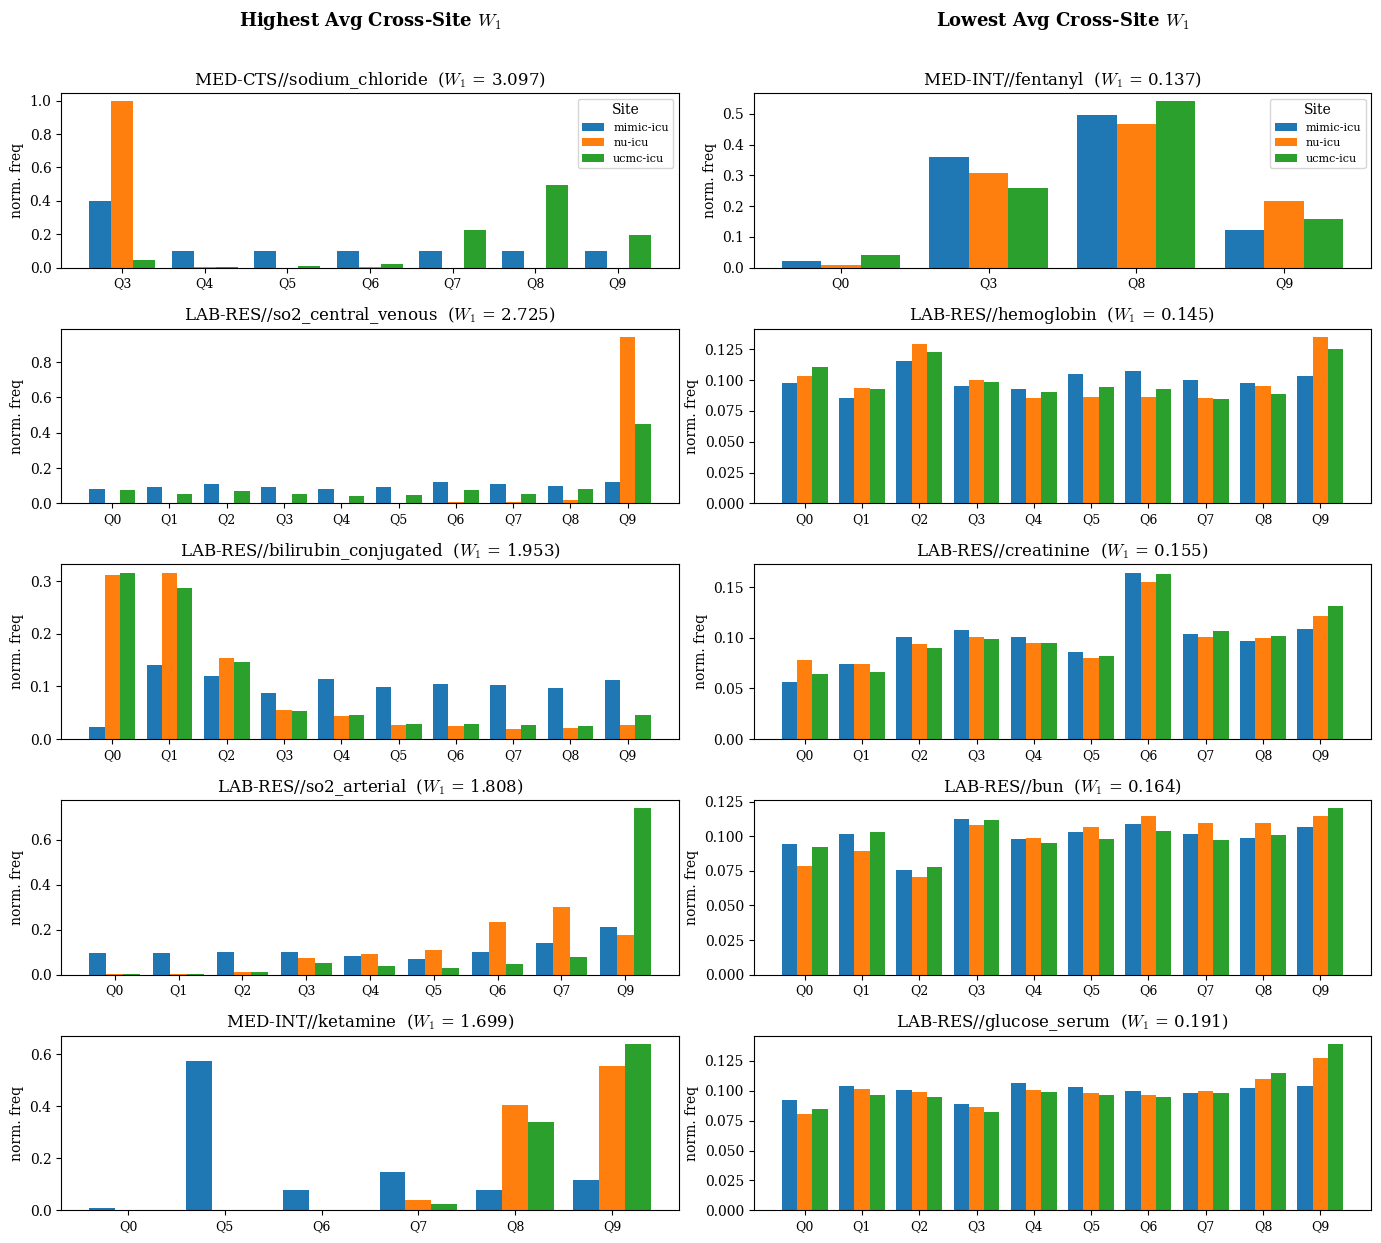

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from itertools import combinations

plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"]
plt.rcParams["mathtext.fontset"] = "cm"

EPS = 1e-12
N_PER_COL = 5

site_display = {"mimic": "MIMIC-ICU", "nu": "NU-ICU", "ucmc": "UCMC-ICU"}

prefix_pattern = r"^(.+)_Q\d$"
qtokens = token_stats_by_site.filter(pl.col("token").str.contains(r"_Q\d$"))
qtokens = qtokens.with_columns(
    pl.col("token").str.extract(prefix_pattern, 1).alias("prefix")
)
prefixes = qtokens["prefix"].unique().to_list()
all_sites = set(token_stats_by_site["site"].unique().to_list())

def symmetric_kl(p, q):
    p = p + EPS; q = q + EPS
    p = p / p.sum(); q = q / q.sum()
    return 0.5 * (np.sum(p * np.log(p / q)) + np.sum(q * np.log(q / p)))

def wasserstein1(p, q):
    return np.sum(np.abs(np.cumsum(p) - np.cumsum(q)))

prefix_dists = {}
prefix_avg_kl = {}

for prefix in prefixes:
    sub = qtokens.filter(pl.col("prefix") == prefix)
    pivoted = sub.sort("token").pivot(values="frequency", index="token", on="site")
    tokens = pivoted["token"].to_list()
    site_cols = [c for c in pivoted.columns if c != "token"]

    dists = {}
    for site in site_cols:
        col = pivoted[site].fill_null(0).to_numpy().astype(float)
        total = col.sum()
        if total <= 0:
            continue
        dists[site] = col / total

    if set(dists.keys()) != all_sites:
        continue

    kls = [wasserstein1(dists[a], dists[b]) for a, b in combinations(dists, 2)]
    prefix_dists[prefix] = (tokens, dists)
    prefix_avg_kl[prefix] = float(np.mean(kls))

ranked_desc = sorted(prefix_avg_kl.items(), key=lambda kv: kv[1], reverse=True)
highest = ranked_desc[:N_PER_COL]
lowest = ranked_desc[-N_PER_COL:][::-1]  # most-similar first

fig, axes = plt.subplots(N_PER_COL, 2, figsize=(14, 2.5 * N_PER_COL))

col_data = [highest, lowest]
col_titles = ["Highest Avg Cross-Site $W_1$", "Lowest Avg Cross-Site $W_1$"]

for col, (data, col_title) in enumerate(zip(col_data, col_titles)):
    for row, (prefix, avg_kl) in enumerate(data):
        ax = axes[row, col]
        tokens, dists = prefix_dists[prefix]
        sites = sorted(dists.keys())
        x = np.arange(len(tokens))
        width = 0.8 / len(sites)
        short_labels = [t.rsplit("_", 1)[-1] for t in tokens]

        for i, site in enumerate(sites):
            ax.bar(x + i * width, dists[site], width,
                   label=site_display.get(site, site))

        ax.set_xticks(x + width * (len(sites) - 1) / 2)
        ax.set_xticklabels(short_labels, fontsize=9)
        ax.set_title(f"{prefix}  ($W_1$ = {avg_kl:.3f})")
        ax.set_ylabel("norm. freq")
        if row == 0:
            ax.legend(fontsize=8, title="Site")

for col, col_title in enumerate(col_titles):
    axes[0, col].annotate(col_title, xy=(0.5, 1.35), xycoords="axes fraction",
                          ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [12]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM

single_site_model_paths = {
    "mimic-icu": "/mnt/bbj-lab/users/burkh4rt/output/c-mimic-icu/mdl-cotorra",
    "ucmc-icu": "/mnt/bbj-lab/users/burkh4rt/output/c-ucmc-icu/mdl-cotorra",
    "nu-icu": "/mnt/bbj-lab/users/burkh4rt/output/c-nu-icu/mdl-cotorra",
}

device = "cuda" if torch.cuda.is_available() else "cpu"
subset_size = 5000  
max_len = 4096


def per_token_nll(model, token_lists: list[list[int]]) -> tuple[torch.Tensor, torch.Tensor]:
    """sum and count of next-token NLL, indexed by target token id"""
    vocab_size = model.config.vocab_size
    sum_nll = torch.zeros(vocab_size)
    count = torch.zeros(vocab_size)
    with torch.no_grad():
        for tokens in token_lists:
            ids = torch.tensor(tokens[:max_len], dtype=torch.long, device=device).unsqueeze(0)
            if ids.shape[1] < 2:
                continue
            logits = model(ids).logits[0, :-1]
            targets = ids[0, 1:]
            nll = F.cross_entropy(logits, targets, reduction="none").cpu()
            sum_nll.scatter_add_(0, targets.cpu(), nll)
            count.scatter_add_(0, targets.cpu(), torch.ones_like(nll))
    return sum_nll, count

In [13]:
overall_nll = []
for model_site, model_path in single_site_model_paths.items():
    model = AutoModelForCausalLM.from_pretrained(model_path).to(device).eval()
    for eval_site in site_paths:
        subset = (
            pl.scan_parquet(f"{site_paths[eval_site]}/tokens_times.parquet")
            .select("tokens")
            .collect()
            .sample(n=subset_size, seed=0)["tokens"]
            .to_list()
        )
        sum_nll, count = per_token_nll(model, subset)
        overall_nll.append(
            {
                "model_site": model_site,
                "eval_site": eval_site,
                "mean_nll": (sum_nll.sum() / count.sum()).item(),
            }
        )
    del model
    torch.cuda.empty_cache()

nll_matrix = (
    pl.DataFrame(overall_nll)
    .pivot(values="mean_nll", index="model_site", on="eval_site")
    .sort("model_site")
)
nll_matrix


Loading weights:   0%|          | 0/83 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/83 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/83 [00:00<?, ?it/s]

model_site,mimic-icu,ucmc-icu,nu-icu
str,f64,f64,f64
"""mimic-icu""",2.440684,4.715703,4.531943
"""nu-icu""",4.263497,3.739225,2.225221
"""ucmc-icu""",4.268599,2.420952,2.840163


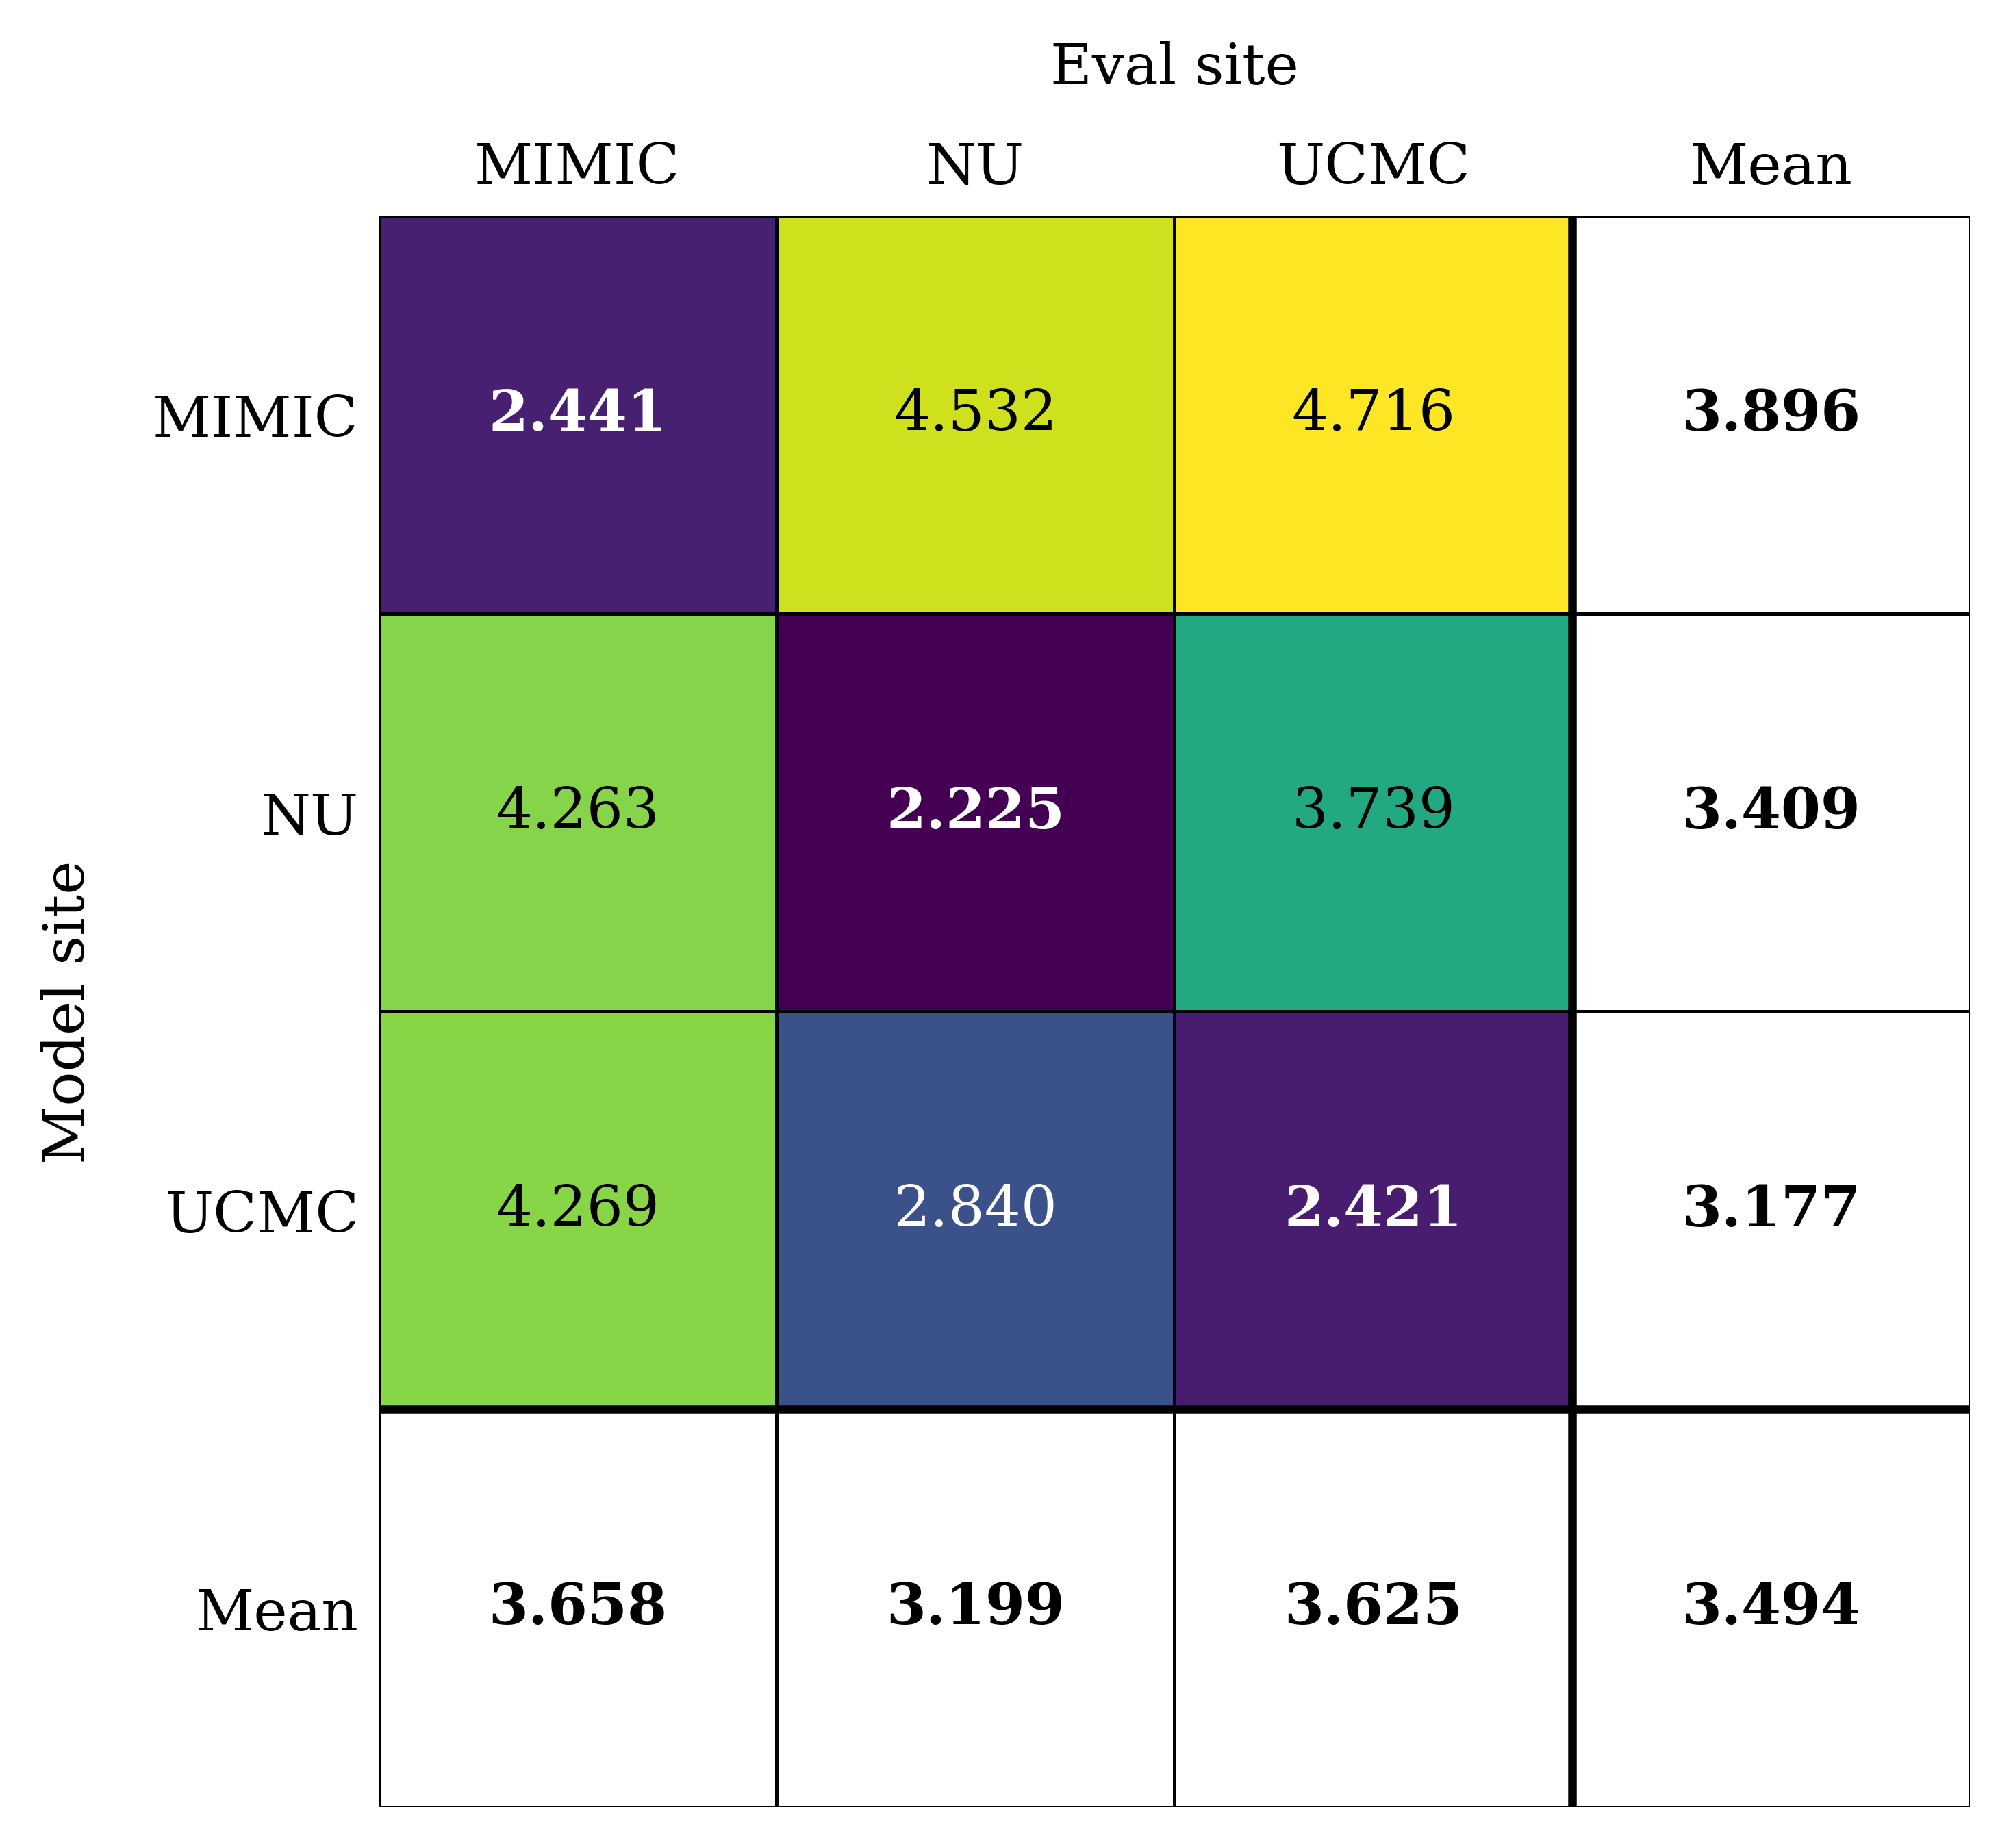

In [14]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"]
plt.rcParams["mathtext.fontset"] = "cm"

sites = nll_matrix["model_site"].to_list()
nll_pd = nll_matrix.to_pandas().set_index("model_site").loc[sites, sites]
M = nll_pd.to_numpy()

site_display = {"mimic-icu": "MIMIC", "nu-icu": "NU", "ucmc-icu": "UCMC"}
display_sites = [site_display.get(s, s) for s in sites]

row_means = M.mean(axis=1)
col_means = M.mean(axis=0)
grand_mean = M.mean()

n = len(sites)
disp = np.full((n + 1, n + 1), np.nan)
disp[:n, :n] = M
disp[:n, n] = row_means
disp[n, :n] = col_means
disp[n, n] = grand_mean

fig, ax = plt.subplots(figsize=(0.9 * (n + 1) + 1.5, 0.9 * (n + 1) + 1.0), dpi = 600)

main = np.full_like(disp, np.nan, dtype=float)
main[:n, :n] = M
im = ax.imshow(main, cmap="viridis", aspect="equal")

labels = display_sites + ["Mean"]
ax.set_xticks(range(n + 1))
ax.set_yticks(range(n + 1))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("Eval site", labelpad=10)
ax.set_ylabel("Model site", labelpad=10)

for k in range(n + 2):
    lw = 1.5 if k == n else 0.6
    ax.axhline(k - 0.5, color="black", linewidth=lw)
    ax.axvline(k - 0.5, color="black", linewidth=lw)

ax.tick_params(axis="both", which="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

vmin, vmax = np.nanmin(M), np.nanmax(M)
for i in range(n + 1):
    for j in range(n + 1):
        v = disp[i, j]
        if np.isnan(v):
            continue
        in_matrix = i < n and j < n
        if in_matrix:
            norm = (v - vmin) / (vmax - vmin + 1e-12)
            color = "white" if norm < 0.6 else "black"
            weight = "bold" if i == j else "normal"
        else:
            color = "black"
            weight = "bold"
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color=color, fontsize=10, fontweight=weight)

ax.set_xlim(-0.5, n + 0.5)
ax.set_ylim(n + 0.5, -0.5)

plt.tight_layout()
plt.show()